In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

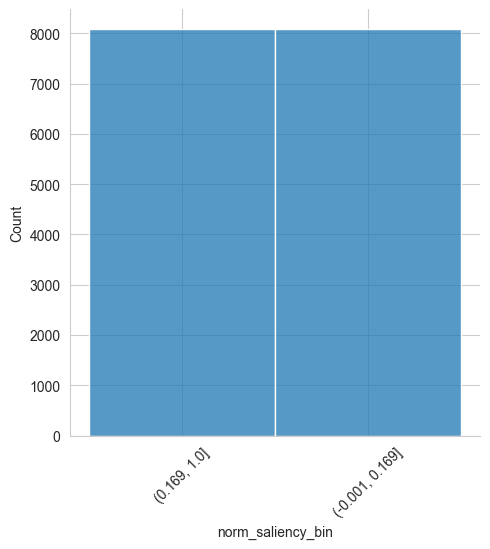

<Figure size 640x480 with 0 Axes>

In [5]:
df = pd.read_csv('data/full_data_GroNLP_bert-base-dutch-cased.csv')
df['norm_saliency_bin'] = pd.qcut(df['norm_saliency'], q=2).astype(str)
# df['norm_saliency_bin'] = pd.cut(df['norm_saliency'], bins=2).astype(str)
graph = sns.displot(df, x='norm_saliency_bin')
plt.xticks(rotation=45)
# plt.savefig(f'data/saliency_dist.png', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.clf()

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_18479/1047526384.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['trial_id']).apply(lambda group: normalize(group)).reset_index(drop=True)


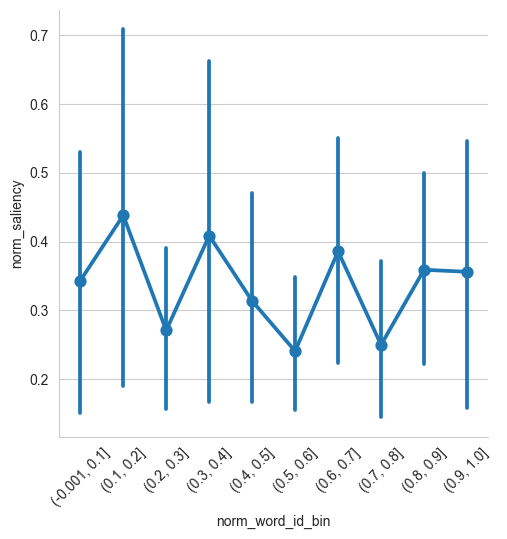

<Figure size 640x480 with 0 Axes>

In [32]:
def normalize(group):
    norm_word_pos = (np.array(group['word_id'].tolist()) - np.min(group['word_id'].tolist())) / (np.max(group['word_id'].tolist()) - np.min(group['word_id'].tolist()))
    group['norm_word_id'] = norm_word_pos
    return group

df = pd.read_csv('data/full_data_GroNLP_bert-base-dutch-cased.csv')
df = df.groupby(['trial_id']).apply(lambda group: normalize(group)).reset_index(drop=True)
df = df[df['trial_id']==0]
df['norm_word_id_bin'] = pd.cut(df['norm_word_id'], bins=10).astype(str)
graph = sns.catplot(df, x='norm_word_id_bin', y='norm_saliency', kind="point")
plt.xticks(rotation=45)
plt.savefig(f'data/dist_saliency_word_ids_bert.png', dpi=300)
plt.show()
plt.clf()

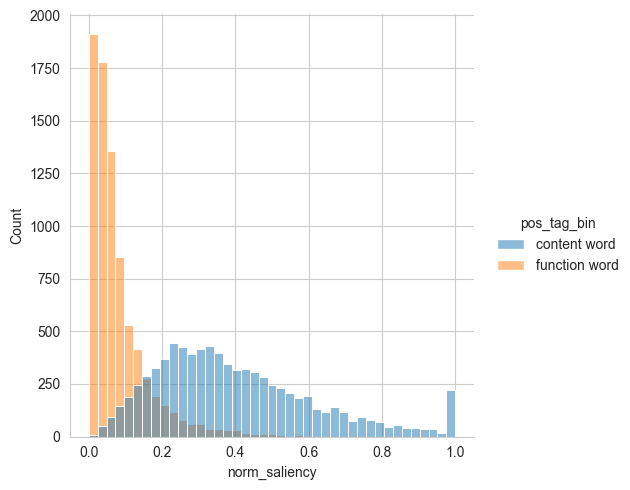

<Figure size 640x480 with 0 Axes>

In [2]:
df = pd.read_csv('data/full_data_GroNLP_bert-base-dutch-cased.csv')
df['pos_tag_bin'] = ['content word' if pos_tag in ['NOUN','VERB','PROPN','ADV','ADJ'] else 'function word' for pos_tag in df['pos_tag'].tolist()]
graph = sns.displot(df, x='norm_saliency', hue='pos_tag_bin')
#plt.savefig(f'data/dist_saliency_postag_bert.png', dpi=300)
plt.show()
plt.clf()

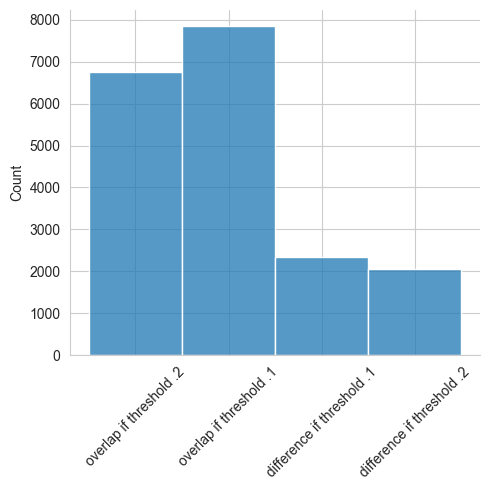

<Figure size 640x480 with 0 Axes>

In [52]:
df = pd.read_csv('data/full_data_GroNLP_bert-base-dutch-cased.csv')
bold = []
for saliency, pos_tag in zip(df['norm_saliency'].tolist(), df['pos_tag'].tolist()):

    if pos_tag in ['NOUN','VERB','PROPN','ADV','ADJ'] and saliency >= .2:
        bold.append('overlap if threshold .2')
    if pos_tag in ['NOUN','VERB','PROPN','ADV','ADJ'] and saliency >= .1:
        bold.append('overlap if threshold .1')

    if pos_tag in ['NOUN','VERB','PROPN','ADV','ADJ'] and saliency < .2:
        bold.append('difference if threshold .2')
    if saliency >= .2 and pos_tag not in ['NOUN','VERB','PROPN','ADV','ADJ']:
        bold.append('difference if threshold .2')

    if pos_tag in ['NOUN','VERB','PROPN','ADV','ADJ'] and saliency < .1:
        bold.append('difference if threshold .1')
    if saliency >= .1 and pos_tag not in ['NOUN','VERB','PROPN','ADV','ADJ']:
        bold.append('difference if threshold .1')

graph = sns.displot(x=bold)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'data/diff_overlap_saliency_pos_bert.png', dpi=300)
plt.show()
plt.clf()

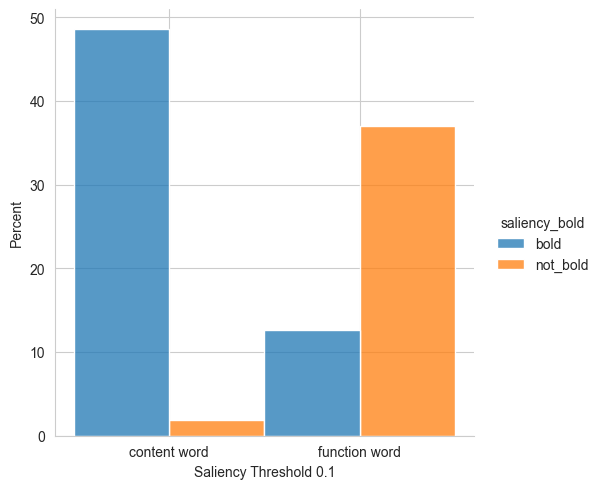

<Figure size 640x480 with 0 Axes>

In [27]:
df = pd.read_csv('data/full_data_GroNLP_bert-base-dutch-cased.csv')
df['pos_tag_bin'] = ['content word' if pos_tag in ['NOUN','VERB','PROPN','ADV','ADJ'] else 'function word' for pos_tag in df['pos_tag'].tolist()]
df['saliency_bold'] = ['bold' if norm_saliency >= .1 else 'not_bold' for norm_saliency in df['norm_saliency'].tolist()]
df['pos_tag_bold'] = ['bold' if pos_tag in ['NOUN','VERB','PROPN','ADV','ADJ'] else 'not_bold' for pos_tag in df['pos_tag'].tolist()]
graph = sns.displot(df, x='pos_tag_bin', hue='saliency_bold', multiple='dodge', stat='percent')
plt.xlabel('Saliency Threshold 0.1')
plt.savefig(f'data/dist_saliency_content_function_bert_1.png', dpi=300)
plt.show()
plt.clf()

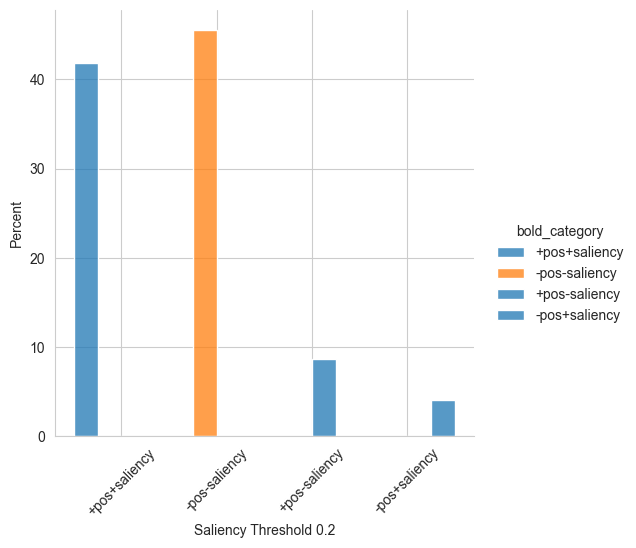

<Figure size 640x480 with 0 Axes>

In [35]:
df = pd.read_csv('data/full_data_GroNLP_bert-base-dutch-cased.csv')
df['saliency_bold'] = ['bold' if norm_saliency >= .2 else 'not_bold' for norm_saliency in df['norm_saliency'].tolist()]
df['pos_tag_bold'] = ['bold' if pos_tag in ['NOUN','VERB','PROPN','ADV','ADJ'] else 'not_bold' for pos_tag in df['pos_tag'].tolist()]
bold_cat = []
for pos_tag, saliency in zip(df['pos_tag_bold'].tolist(), df['saliency_bold'].tolist()):
    if pos_tag == 'bold' and saliency == 'bold':
        bold_cat.append('+pos+saliency')
    elif pos_tag == 'bold' and saliency == 'not_bold':
        bold_cat.append('+pos-saliency')
    elif pos_tag == 'not_bold' and saliency == 'bold':
        bold_cat.append('-pos+saliency')
    else:
        bold_cat.append('-pos-saliency')
df['bold_category'] = bold_cat
# df = df[df['bold_category'] != 'not_bold']
palette = {'+pos+saliency': '#1f77b4', '+pos-saliency': '#1f77b4', '-pos+saliency': '#1f77b4', '-pos-saliency': '#ff7f0e'}
graph = sns.displot(df, x='bold_category', stat='percent', palette=palette, hue='bold_category', multiple='dodge')
plt.xlabel('Saliency Threshold 0.2')
plt.xticks(rotation=45)
plt.savefig(f'data/dist_saliency_postag_bold_bert_2.png', dpi=300)
plt.show()
plt.clf()

In [19]:
df = pd.read_csv('data/full_data_GroNLP_bert-base-dutch-cased.csv')
text_length = []
for i, group in df.groupby('trial_id'):
    text_length.append(group['word_id'].tolist()[-1])
print(np.mean(text_length), np.std(text_length))

88.17 6.689626297484786
